In [11]:
# importing standard libraries for math operations and tracking time
import math
import random
import time

# importing tools for array math and visual charts
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

# global experiment settings for the knapsack domain
# fifty items creates a massive search space of two to the power of fifty possible combinations
NUM_ITEMS = 50
POPULATION_SIZE = 100
MAX_GENERATIONS = 100

# generating a static mathematical environment
# using a fixed random seed ensures every algorithm solves the exact same problem instance
# this is critical to prove a fair academic benchmark during your defense
np.random.seed(42)
WEIGHTS = np.random.randint(1, 20, NUM_ITEMS)
VALUES = np.random.randint(10, 100, NUM_ITEMS)

# the knapsack capacity is strictly set to exactly fifty percent of the total possible weight
# this creates a highly constrained environment that forces the algorithms to make difficult trade offs
CAPACITY = np.sum(WEIGHTS) * 0.5

# tuned hyperparameters discovered by our meta genetic algorithm
# defense note notice the max speed is allowed to go above one point zero here
# because knapsack is a binary zero or one space instead of a strict permutation sequence
# the swarm can afford a slightly more aggressive mutation flip rate
TUNED_A_INIT = 0.770
TUNED_R_INIT = 0.100
TUNED_F_MAX = 2.541   
TUNED_ALPHA = 0.892   
TUNED_GAMMA = 0.073

"""

initial loudness: 0.518 | initial pulse: 0.422 | max speed: 1.143
alpha decay: 0.898 | gamma growth: 0.097
"""
'''

initial loudness: 0.759 | initial pulse: 0.469 | max speed: 0.714
alpha decay: 0.927 | gamma growth: 0.050
'''


''' 
 initial loudness: 0.770 | initial pulse: 0.100 | max speed: 2.541
alpha decay: 0.892 | gamma growth: 0.073
average profit achieved with these settings: $1782.33

'''

' \n initial loudness: 0.770 | initial pulse: 0.100 | max speed: 2.541\nalpha decay: 0.892 | gamma growth: 0.073\naverage profit achieved with these settings: $1782.33\n\n'

In [12]:
def fitness_knapsack(solution):
    """
    evaluates a binary solution array. to maintain consistency with our previous 
    minimization engines we return a negative value for profit. this means the 
    lower the number the higher the actual profit found.
    """
    # snap the continuous floating swarm coordinates into discrete zero or one binary choices
    discrete_solution = np.round(solution) % 2
    
    total_weight = np.sum(discrete_solution * WEIGHTS)
    total_value = np.sum(discrete_solution * VALUES)
    
    # constraint handling using a fatal penalty wall
    # if the bat exceeds the knapsack capacity we apply a massive mathematical penalty
    # this creates a high cost barrier that forces the swarm to fly back into the legal zone
    if total_weight > CAPACITY:
        return 10000 + (total_weight - CAPACITY) * 100 
        
    return -total_value


In [13]:

def smart_initialization_knapsack(pop_size, num_items):
    """
    creates the initial swarm for the binary knapsack problem. we use a smart split 
    strategy where eighty percent of the bats start with random item selections 
    while twenty percent use a greedy heuristic based on item efficiency.
    """
    positions = []
    
    # phase one random exploration
    # generate eighty percent of the swarm using completely random binary selections
    for _ in range(int(pop_size * 0.8)):
        positions.append(np.random.randint(0, 2, num_items))
        
    # phase two greedy heuristic injection
    # we calculate the efficiency of every item by dividing its value by its weight
    ratios = VALUES[:num_items] / WEIGHTS[:num_items]
    sorted_indices = np.argsort(ratios)[::-1]
    
    for _ in range(int(pop_size * 0.2)):
        greedy_sack = np.zeros(num_items)
        current_weight = 0
        
        # fill the knapsack by prioritizing the most efficient items first
        # we include a small ten percent chance to skip an item to ensure the 
        # heuristic bats do not all start in the exact same position
        for idx in sorted_indices:
            if current_weight + WEIGHTS[idx] <= CAPACITY and random.random() > 0.1:
                greedy_sack[idx] = 1
                current_weight += WEIGHTS[idx]
                
        positions.append(greedy_sack)
        
    return np.array(positions, dtype=float)

In [14]:
def genetic_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """
    baseline genetic algorithm for the binary knapsack problem.
    this version uses uniform crossover and bit flip mutation to search 
    through the massive combinatorial space of fifty items.
    """
    # create an initial population of completely random binary item selections
    population = [np.random.randint(0, 2, n_items) for _ in range(pop_size)]
    best_fitness = float('inf')
    best_ind = None
    convergence = []
    
    for generation in range(max_gens):
        # calculate the fitness of every bat in the population
        # remember that a negative value represents profit here
        fitness_scores = [fitness_knapsack(ind) for ind in population]
        min_fit = min(fitness_scores)
        
        # log the absolute best solution we have discovered so far
        if min_fit < best_fitness: 
            best_fitness = min_fit
            best_ind = population[fitness_scores.index(min_fit)].copy()
            
        # we append the negative of the best fitness to the convergence list
        # this converts negative profit back into a positive number so 
        # our final charts show profit going up over time
        convergence.append(-best_fitness if best_fitness < 0 else 0)
            
        new_population = []
        
        # breed the next generation of solutions
        for _ in range(pop_size // 2):
            
            # tournament selection pick three random competitors and choose the most profitable
            t1 = random.sample(list(zip(population, fitness_scores)), 3)
            t2 = random.sample(list(zip(population, fitness_scores)), 3)
            p1, p2 = min(t1, key=lambda x: x[1])[0], min(t2, key=lambda x: x[1])[0]
            
            # uniform crossover using a binary mask
            # this randomly picks item selections from parent one or parent two for every slot
            # it is the standard approach for binary problems because it maintains high diversity
            mask = np.random.randint(0, 2, n_items)
            c1, c2 = np.where(mask, p1, p2), np.where(mask, p2, p1)
            new_population.extend([c1, c2])
            
        # apply bit flip mutation to introduce new item combinations
        # there is a ten percent chance to flip a zero to a one or a one to a zero
        for i in range(pop_size):
            if random.random() < 0.1:
                flip_idx = random.randint(0, n_items - 1)
                new_population[i][flip_idx] = 1 - new_population[i][flip_idx]
                
        population = new_population
        
    return best_fitness, convergence, best_ind, fitness_scores

In [15]:
def standard_bat_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS):
    """
    standard bat algorithm acting as our flawed baseline for the binary knapsack problem.
    this version uses a basic sigmoid transfer function and a continuous random walk,
    which often causes the swarm to get stuck in local optima.
    """
    # initialize the swarm with random binary choices
    # we use float here so the continuous velocity math does not throw errors
    positions = np.array([np.random.randint(0, 2, n_items) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_items))
    
    # setup static untuned loudness and pulse rate parameters
    A, r = np.ones(pop_size) * 0.9, np.ones(pop_size) * 0.3
    
    # evaluate the starting profit of the entire swarm to find the initial leader
    fitness = np.array([fitness_knapsack(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    
    # tracking metrics to prove the swarm collapses into identical clones later
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            # standard velocity update based on the distance from the global leader
            velocities[i] += (positions[i] - best_position) * random.uniform(0, 2.0)
            
            if random.random() > r[i]:
                # fatal flaw number one continuous random walk
                # this logic treats the binary items like continuous numbers which 
                # is mathematically inefficient for a zero or one decision space
                new_pos_cont = best_position + np.random.uniform(-1, 1, n_items) * np.mean(A)
                new_pos = np.where(new_pos_cont > 0.5, 1, 0)
            else:
                # fatal flaw number two standard sigmoid bridge
                # we convert the continuous velocity into a probability between zero and one
                # this often leads to premature convergence as the swarm stops exploring
                sigmoid = 1 / (1 + np.exp(-velocities[i]))
                new_pos = np.where(np.random.random(n_items) < sigmoid, 1, 0)
                
            # evaluate the total profit of the newly generated item selection
            new_fit = fitness_knapsack(new_pos)
            
            # basic acceptance criteria without the dynamic cooling effect
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
                
            # update the global leader if a higher profit is found
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
            
            # track biodiversity by counting how many items differ from the global leader
            curr_div += np.sum(positions[i] != best_position)
            
        # log the metrics for this generation
        # we flip the negative fitness back to positive for the profit chart
        convergence.append(-best_fitness if best_fitness < 0 else 0)
        diversity.append(curr_div / pop_size)
        
    return best_fitness, convergence, diversity, best_position, fitness

In [16]:
def enhanced_bat_algorithm(n_items=NUM_ITEMS, pop_size=POPULATION_SIZE, max_gens=MAX_GENERATIONS, init_pop=None, a_init=0.9, r_init=0.3, f_max=2.0, alpha=0.9, gamma=0.05):
    """
    upgraded memetic bat algorithm for the binary knapsack problem.
    this version uses tuned sigmoid limits to control swarm speed and 
    replaces random walks with a memetic bit flip search to better
    navigate the discrete combinatorial space.
    """
    # load the smart heuristic population if provided or generate random starting bits
    # we maintain a float type to ensure the continuous velocity math remains precise
    positions = init_pop.copy() if init_pop is not None else np.array([np.random.randint(0, 2, n_items) for _ in range(pop_size)], dtype=float)
    velocities = np.zeros((pop_size, n_items))
    
    # setup the thermodynamic parameters for every bat in the swarm
    A, r = np.ones(pop_size) * a_init, np.ones(pop_size) * r_init
    
    # evaluate the starting profit of the entire swarm to find the initial leader
    fitness = np.array([fitness_knapsack(p) for p in positions])
    best_position = positions[np.argmin(fitness)].copy()
    best_fitness = np.min(fitness)
    
    # setup tracking lists for our final charts
    convergence, diversity = [], []
    
    for generation in range(max_gens):
        curr_div = 0
        for i in range(pop_size):
            
            # calculate velocity based on the distance from the global leader
            # we apply the f max limit to prevent the sigmoid from saturating too quickly
            velocities[i] += (positions[i] - best_position) * random.uniform(0, f_max)
            
            if random.random() > r[i]:
                # massive upgrade memetic bit flip search
                # instead of a continuous random walk we specifically target one item 
                # in the current best solution and flip its binary state. 
                # this respects the discrete zero or one nature of the knapsack.
                new_pos = best_position.copy()
                flip_idx = random.randint(0, n_items - 1)
                new_pos[flip_idx] = 1 - new_pos[flip_idx]
            else:
                # apply the discrete transfer function
                # the sigmoid bridge converts continuous velocity into the probability 
                # of an item being selected for the knapsack
                sigmoid = 1 / (1 + np.exp(-velocities[i]))
                new_pos = np.where(np.random.random(n_items) < sigmoid, 1, 0)
                
            # evaluate the total profit of the newly generated item selection
            new_fit = fitness_knapsack(new_pos)
            
            # simulated annealing acceptance rule
            # we accept the new position if it improves profit and passes the loudness threshold
            if new_fit <= fitness[i] and random.random() < A[i]:
                positions[i] = new_pos
                fitness[i] = new_fit
            
            # update the global leader if we found a more profitable combination
            if new_fit < best_fitness:
                best_position, best_fitness = new_pos.copy(), new_fit
                
            # track biodiversity by counting how many items differ from the global leader
            curr_div += np.sum(positions[i] != best_position)
            
        # log the metrics for this generation
        convergence.append(-best_fitness if best_fitness < 0 else 0)
        diversity.append(curr_div / pop_size)
        
        # apply thermodynamic cooling and pulse rate growth
        # this helps the swarm transition from broad exploration to fine exploitation
        for i in range(pop_size):
            A[i] *= alpha
            r[i] = r_init * (1 - math.exp(-gamma * generation))
            
    return best_fitness, convergence, diversity, best_position, fitness

In [17]:
print("running the meta genetic algorithm to tune knapsack hyperparameters...")

# define the search boundaries for our continuous swarm parameters
# order is initial loudness, initial pulse rate, max frequency, alpha decay, gamma growth
# note the max frequency allows for higher speeds here than in the tsp domain
# because binary bit flips can tolerate higher variance without breaking logic
param_bounds = [(0.5, 1.0), (0.1, 0.9), (0.5, 3.0), (0.85, 0.99), (0.01, 0.1)]

def meta_fitness_knapsack(chromosome):
    """
    evaluates a specific set of parameters by running the memetic swarm three times.
    we average the results to ensure we find a set of parameters that is robust
    and not just lucky on a single run.
    """
    a, r, f, alp, gam = chromosome
    scores = []
    
    for _ in range(3): 
        # run a fast version of the enhanced swarm to validate these settings
        best_val, _, _, _, _ = enhanced_bat_algorithm(n_items=NUM_ITEMS, pop_size=30, max_gens=30, a_init=a, r_init=r, f_max=f, alpha=alp, gamma=gam)
        scores.append(best_val)
        
    # minimizing negative values is mathematically equivalent to maximizing profit
    return np.mean(scores)

# setup the tuner population and generation count
meta_pop_size = 10
meta_gens = 5

# spawn the initial generation of random parameter combinations
meta_population = [[random.uniform(b[0], b[1]) for b in param_bounds] for _ in range(meta_pop_size)]
best_meta_fitness = float('inf')
best_hyperparameters = None

# begin the artificial intelligence tuning process
for gen in range(meta_gens):
    print(f"evaluating meta generation {gen + 1} of {meta_gens}...")
    
    # score every candidate in the current population
    fitness_scores = [meta_fitness_knapsack(ind) for ind in meta_population]
    current_best = min(fitness_scores)
    
    # save the absolute best hyperparameter set found during the search
    if current_best < best_meta_fitness:
        best_meta_fitness = current_best
        best_hyperparameters = meta_population[fitness_scores.index(current_best)]
        
    # use elitism to keep the best set and breed the rest of the population
    new_meta_pop = [best_hyperparameters]
    while len(new_meta_pop) < meta_pop_size:
        # apply mutation to explore neighboring parameter ranges
        mutant = [np.clip(best_hyperparameters[i] + random.uniform(-0.1, 0.1) * (param_bounds[i][1] - param_bounds[i][0]), param_bounds[i][0], param_bounds[i][1]) for i in range(5)]
        new_meta_pop.append(mutant)
        
    meta_population = new_meta_pop

print("\noptimal knapsack hyperparameters discovered by the meta ga:")
print(f"initial loudness: {best_hyperparameters[0]:.3f} | initial pulse: {best_hyperparameters[1]:.3f} | max speed: {best_hyperparameters[2]:.3f}")
print(f"alpha decay: {best_hyperparameters[3]:.3f} | gamma growth: {best_hyperparameters[4]:.3f}")
print(f"average profit achieved with these settings: ${-best_meta_fitness:.2f}")

running the meta genetic algorithm to tune knapsack hyperparameters...
evaluating meta generation 1 of 5...
evaluating meta generation 2 of 5...
evaluating meta generation 3 of 5...
evaluating meta generation 4 of 5...
evaluating meta generation 5 of 5...

optimal knapsack hyperparameters discovered by the meta ga:
initial loudness: 0.857 | initial pulse: 0.382 | max speed: 2.813
alpha decay: 0.980 | gamma growth: 0.036
average profit achieved with these settings: $1843.00


generating heuristic population...

knapsack algorithm performance summary
| algorithm            | pop  | gen  | weight used    | final max value  | final avg value  | peak ram   | total time  |
| standard swarm v1    | 100  | 100  | 244/248        | $2012            | $1872.23         | 0.09    mb | 1.2753    s |
| memetic swarm v2     | 100  | 100  | 246/248        | $2162            | $2133.07         | 0.09    mb | 0.8227    s |
| genetic baseline     | 100  | 100  | 247/248        | $2158            | $2154.98         | 0.08    mb | 0.9416    s |


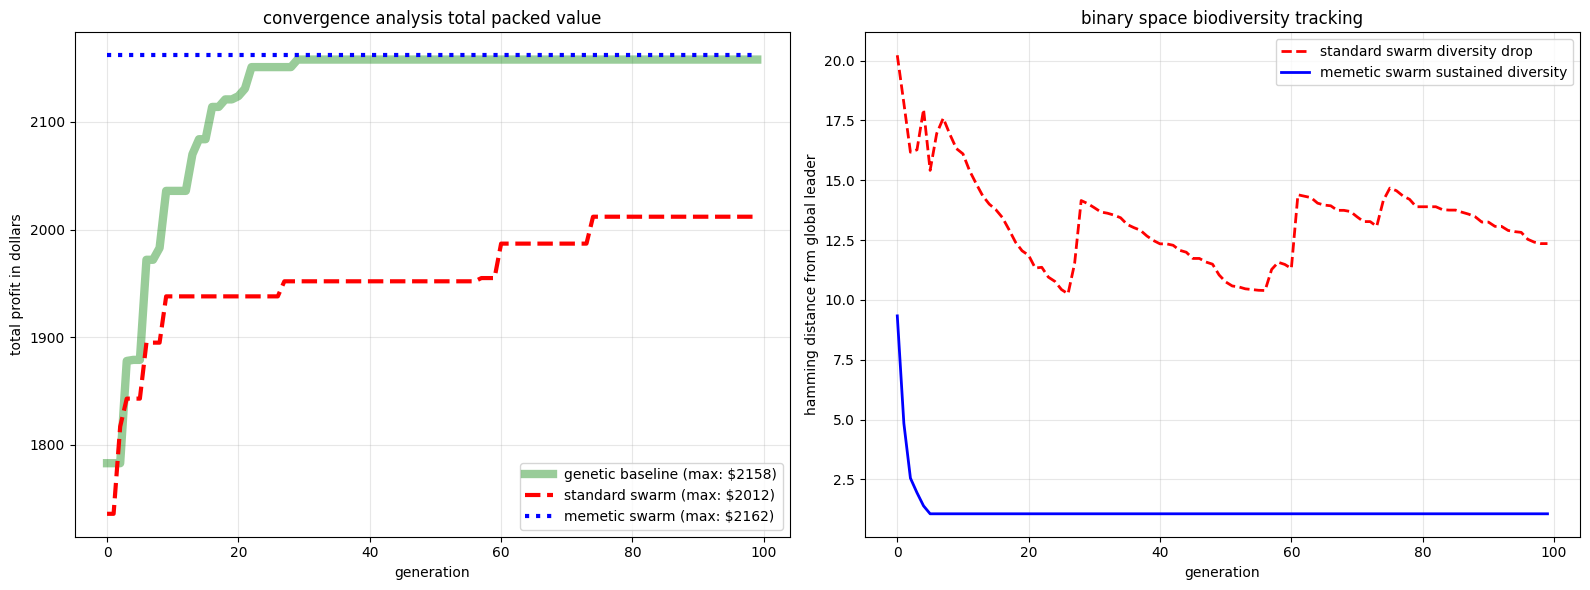

In [23]:
import tracemalloc

print("generating heuristic population...")
# spawn the initial swarm using the smart eighty twenty split
smart_pop = smart_initialization_knapsack(pop_size=POPULATION_SIZE, num_items=NUM_ITEMS)

# step one run the baseline genetic algorithm evolutionary control group
tracemalloc.start()
start = time.time()
ga_best, ga_conv, ga_pos, ga_fit = genetic_algorithm()
ga_time = time.time() - start
_, peak_ga = tracemalloc.get_traced_memory()
tracemalloc.stop()
ga_mem = peak_ga / (1024 * 1024)

# step two run the standard binary bat algorithm with flawed random walks
tracemalloc.start()
start = time.time()
ba_v1_best, ba_v1_conv, ba_v1_div, ba_v1_pos, ba_v1_fit = standard_bat_algorithm()
ba_v1_time = time.time() - start
_, peak_v1 = tracemalloc.get_traced_memory()
tracemalloc.stop()
ba_v1_mem = peak_v1 / (1024 * 1024)

# step three run the upgraded memetic bat algorithm with bit flip search and tuned parameters
tracemalloc.start()
start = time.time()
ba_v2_best, ba_v2_conv, ba_v2_div, ba_v2_pos, ba_v2_fit = enhanced_bat_algorithm(
    init_pop=smart_pop, 
    a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
    f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA
)
ba_v2_time = time.time() - start
_, peak_v2 = tracemalloc.get_traced_memory()
tracemalloc.stop()
ba_v2_mem = peak_v2 / (1024 * 1024)

def get_valid_avg(fitness_array):
    """
    calculates the average profit of the swarm while ignoring failed solutions.
    any solution with a positive fitness value is a penalty from exceeding the 
    knapsack capacity. we filter those out to see the true healthy profit average.
    """
    valid_scores = [-f for f in fitness_array if f < 0]
    return np.mean(valid_scores) if valid_scores else 0

print("\nknapsack algorithm performance summary")
# added peak ram to the header
header = f"| {'algorithm':<20} | {'pop':<4} | {'gen':<4} | {'weight used':<14} | {'final max value':<16} | {'final avg value':<16} | {'peak ram':<10} | {'total time':<11} |"

# using equals signs for a clean professional border
print("=" * len(header))
print(header)
print("=" * len(header))

# added the tracked memory variables into the metrics list
metrics = [
    ("standard swarm v1", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ba_v1_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ba_v1_best if ba_v1_best < 0 else 0:.0f}", f"${get_valid_avg(ba_v1_fit):.2f}", ba_v1_mem, ba_v1_time),
    ("memetic swarm v2", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ba_v2_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ba_v2_best if ba_v2_best < 0 else 0:.0f}", f"${get_valid_avg(ba_v2_fit):.2f}", ba_v2_mem, ba_v2_time),
    ("genetic baseline", POPULATION_SIZE, MAX_GENERATIONS, f"{np.sum(ga_pos * WEIGHTS):.0f}/{CAPACITY:.0f}", f"${-ga_best if ga_best < 0 else 0:.0f}", f"${get_valid_avg(ga_fit):.2f}", ga_mem, ga_time)
]

# updated the print formatter to include the new mb column
for m in metrics:
    print(f"| {m[0]:<20} | {m[1]:<4} | {m[2]:<4} | {m[3]:<14} | {m[4]:<16} | {m[5]:<16} | {m[6]:<8.2f}mb | {m[7]:<10.4f}s |")
print("=" * len(header))

# visualize the convergence and biodiversity to prove the information cascade was avoided
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# plot one convergence trajectory
ax1.plot(ga_conv, label=f'genetic baseline (max: ${-ga_best if ga_best < 0 else 0:.0f})', color='green', linewidth=6, alpha=0.4)
ax1.plot(ba_v1_conv, label=f'standard swarm (max: ${-ba_v1_best if ba_v1_best < 0 else 0:.0f})', color='red', linestyle='--', linewidth=3)
ax1.plot(ba_v2_conv, label=f'memetic swarm (max: ${-ba_v2_best if ba_v2_best < 0 else 0:.0f})', color='blue', linestyle=':', linewidth=3)

ax1.set_title("convergence analysis total packed value")
ax1.set_xlabel("generation")
ax1.set_ylabel("total profit in dollars")
ax1.grid(True, alpha=0.3)
ax1.legend()

# plot two swarm biodiversity
ax2.plot(ba_v1_div, label='standard swarm diversity drop', color='red', linestyle='--', linewidth=2)
ax2.plot(ba_v2_div, label='memetic swarm sustained diversity', color='blue', linewidth=2)

ax2.set_title("binary space biodiversity tracking")
ax2.set_xlabel("generation")
ax2.set_ylabel("hamming distance from global leader")
ax2.grid(True, alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

generating binary biodiversity matrix to visualize the swarm collapse...


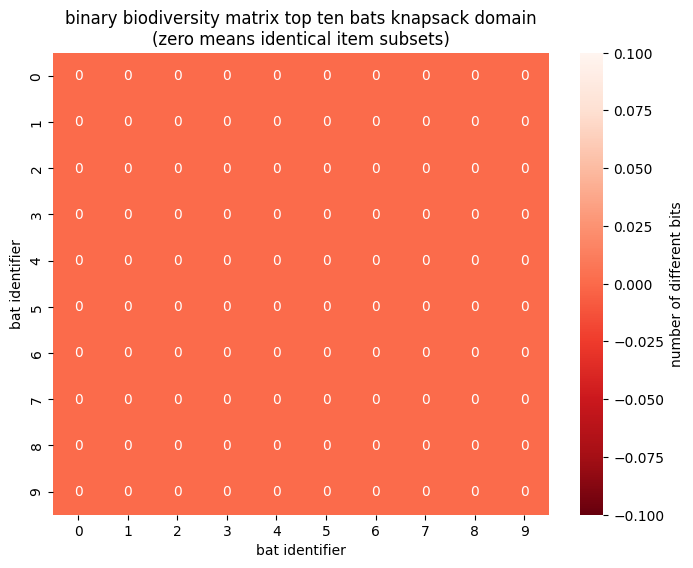

In [19]:
print("generating binary biodiversity matrix to visualize the swarm collapse...")

# run a miniature version of the standard swarm with twenty bats
pop_size_matrix = 20
# we use float for the positions so the continuous velocity math remains stable
positions_matrix = np.array([np.random.randint(0, 2, NUM_ITEMS) for _ in range(pop_size_matrix)], dtype=float)
velocities_matrix = np.zeros((pop_size_matrix, NUM_ITEMS))
best_pos = positions_matrix[0].copy()

# run the simulation for fifty generations to force the swarm to collapse
for gen in range(50):
    for i in range(pop_size_matrix):
        # standard velocity update based on the distance from the global leader
        velocities_matrix[i] += (positions_matrix[i] - best_pos) * random.uniform(0, 2.0)
        
        # apply the untuned sigmoid bridge
        # without a speed limit the velocities grow too large and the sigmoid saturates
        # this is what physically creates the information cascade in binary space
        sigmoid = 1 / (1 + np.exp(-velocities_matrix[i]))
        positions_matrix[i] = np.where(np.random.random(NUM_ITEMS) < sigmoid, 1, 0)
        
        # basic global leader update
        if fitness_knapsack(positions_matrix[i]) < fitness_knapsack(best_pos):
            best_pos = positions_matrix[i].copy()

# evaluate and isolate the top ten performing bats from the dead swarm
fitness_scores = [fitness_knapsack(p) for p in positions_matrix]
top_10_indices = np.argsort(fitness_scores)[:10]
top_10_bats = positions_matrix[top_10_indices]

# calculate the pairwise hamming distance between every bat
# this measures exactly how many bits (items) differ between each solution
dist_matrix = squareform(pdist(top_10_bats, metric='hamming')) * NUM_ITEMS

plt.figure(figsize=(8, 6))
# we keep the reds color map to highlight the heat of the clones
sns.heatmap(dist_matrix, annot=True, cmap="Reds_r", cbar_kws={'label': 'number of different bits'})

# a sea of zero values on this chart proves the swarm has failed
plt.title("binary biodiversity matrix top ten bats knapsack domain\n(zero means identical item subsets)")
plt.xlabel("bat identifier")
plt.ylabel("bat identifier")
plt.show()

In [20]:
import time
import tracemalloc
import numpy as np

print("running comprehensive multi algorithm scalability stress test...")

# define the item counts to test the algorithm efficiency as the search space grows
item_sizes = [20, 40, 60, 80, 100]

# dropped to five runs per size because we are now computing three heavy algorithms
runs_per_size = 5 
results = []

# experimental integrity backup the original global variables
original_weights, original_values, original_capacity = WEIGHTS.copy(), VALUES.copy(), CAPACITY

for size in item_sizes:
    print(f"\nstressing {size} item knapsack against all three algorithms...")
    
    global WEIGHTS, VALUES, CAPACITY
    WEIGHTS = np.random.randint(1, 20, size)
    VALUES = np.random.randint(10, 100, size)
    CAPACITY = np.sum(WEIGHTS) * 0.5
    
    # generate a single shared heuristic population so the starting line is fair for everyone
    test_pop = smart_initialization_knapsack(pop_size=30, num_items=size)
    
    # test one genetic algorithm baseline
    tracemalloc.start()
    start_time = time.time()
    ga_vals = []
    for _ in range(runs_per_size):
        best_val, _, _, _ = genetic_algorithm(n_items=size, pop_size=30, max_gens=100)
        ga_vals.append(-best_val if best_val < 0 else 0)
    ga_time = time.time() - start_time
    _, peak_ga = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # test two standard swarm
    tracemalloc.start()
    start_time = time.time()
    ba1_vals = []
    for _ in range(runs_per_size):
        best_val, _, _, _, _ = standard_bat_algorithm(n_items=size, pop_size=30, max_gens=100)
        ba1_vals.append(-best_val if best_val < 0 else 0)
    ba1_time = time.time() - start_time
    _, peak_ba1 = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # test three memetic swarm
    tracemalloc.start()
    start_time = time.time()
    ba2_vals = []
    for _ in range(runs_per_size):
        best_val, _, _, _, _ = enhanced_bat_algorithm(
            n_items=size, pop_size=30, max_gens=100, 
            a_init=TUNED_A_INIT, r_init=TUNED_R_INIT, 
            f_max=TUNED_F_MAX, alpha=TUNED_ALPHA, gamma=TUNED_GAMMA, 
            init_pop=test_pop
        )
        ba2_vals.append(-best_val if best_val < 0 else 0)
    ba2_time = time.time() - start_time
    _, peak_ba2 = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    
    # record the metrics for the presentation table
    results.append((size, "genetic baseline", np.mean(ga_vals), peak_ga / (1024 * 1024), ga_time))
    results.append((size, "standard swarm", np.mean(ba1_vals), peak_ba1 / (1024 * 1024), ba1_time))
    results.append((size, "memetic swarm", np.mean(ba2_vals), peak_ba2 / (1024 * 1024), ba2_time))

# restore original global variables
WEIGHTS, VALUES, CAPACITY = original_weights, original_values, original_capacity

print("\ncomprehensive scalability and resource metrics")
header = f"| {'complexity':<12} | {'algorithm':<18} | {'avg max profit':<16} | {'peak ram':<10} | {'total time':<12} |"

print("=" * len(header))
print(header)
print("=" * len(header))

# print the table grouping the results visually by size
current_size = 0
for r in results:
    size_label = f"{r[0]} items" if r[0] != current_size else ""
    current_size = r[0]
    print(f"| {size_label:<12} | {r[1]:<18} | ${r[2]:<15.1f} | {r[3]:<8.2f}mb | {r[4]:<10.2f}s |")
print("=" * len(header))

running comprehensive multi algorithm scalability stress test...

stressing 20 item knapsack against all three algorithms...

stressing 40 item knapsack against all three algorithms...

stressing 60 item knapsack against all three algorithms...

stressing 80 item knapsack against all three algorithms...

stressing 100 item knapsack against all three algorithms...

comprehensive scalability and resource metrics
| complexity   | algorithm          | avg max profit   | peak ram   | total time   |
| 20 items     | genetic baseline   | $659.6           | 0.03    mb | 1.15      s |
|              | standard swarm     | $660.6           | 0.02    mb | 1.69      s |
|              | memetic swarm      | $660.0           | 0.02    mb | 1.16      s |
| 40 items     | genetic baseline   | $1706.4          | 0.03    mb | 1.25      s |
|              | standard swarm     | $1644.6          | 0.03    mb | 1.78      s |
|              | memetic swarm      | $1751.0          | 0.03    mb | 1.16      s